In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from random import randint,random

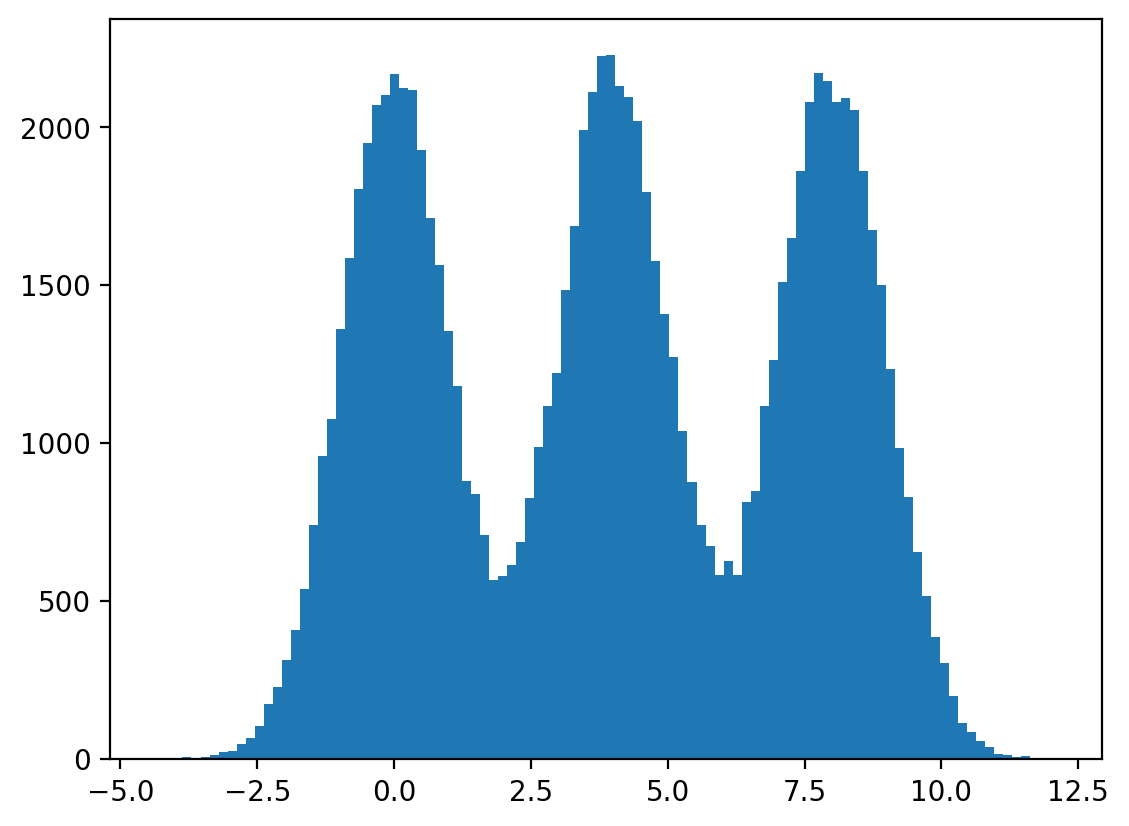

In [47]:
mu = [randint(0,10) for i in range(3)]
sigma = np.ones(3)#[randint(2,5)*random() for i in range(3)]
p = [random() for i in range(5)]
p[2] = 1 - p[0] - p[1]

N = 100000
echantillon_norm = [norm(mu[i], sigma[i]).rvs(N) for i in range(3)]
echantillon = [echantillon_norm[randint(0,2)][randint(0,N-1)] for i in range(N)]

plt.hist(echantillon, bins = 100)
plt.show()

In [3]:
F = 3

In [24]:
def EM_algorithm_step(pi, theta, x, n, F):
  new_rho = np.zeros((n,F))
  s = np.zeros(n)
  p = np.zeros((n,F))
  for i in range(n):
    for y in range(F):
      p[i,y] = 1/np.sqrt(2*np.pi*theta[y,1])*np.exp(-(x[i]-theta[y,0])**2/(2*theta[y,1]))
      s[i]+=pi[y]*p[i,y]
  for i in range(n):
    for y in range(F):
      new_rho[i,y] = pi[y]*p[i,y]/s[i]
  for y in range(F):
    new_pi=0
    for i in range(n):
      new_pi += new_rho[i,y]/n
    pi[y] = new_pi
  new_theta = np.zeros((F,2))
  for y in range(F):
    s1 = 0
    for i in range(n):
      s1 += new_rho[i,y]*x[i]
    new_theta[y,0] = s1/(n*pi[y])
    s2 = 0
    for i in range(n):
      s2 += new_rho[i,y]*(x[i] - new_theta[y,0])**2
    new_theta[y,1] = s2/(n*pi[y])
  return pi, new_theta

def EM_algorithm(n: int, F: int, x: np.array, pi0: np.array, theta0: np.array):
  pi, theta = pi0, theta0
  liste_pi, liste_theta = [np.copy(pi)], [np.copy(theta)]
  j=0
  while j<20:
    pi, theta = EM_algorithm_step(pi, theta, x, n, F)
    liste_pi.append(np.copy(pi))
    liste_theta.append(np.copy(theta))
    j += 1
  return pi, theta, liste_pi, liste_theta


In [ ]:
indices = np.arange(N)
np.random.shuffle(indices)
echantillon_shuffled = []
for i in indices:
  echantillon_shuffled.append(echantillon[i])
pi0 = np.zeros(F)
theta0 = np.zeros((F,2))
for y in range(F):
  pi0[y] = 1/F

for y in range(F):
  theta0[y,0] += np.mean(echantillon_shuffled[y*N//F : (y+1)*N//F])
  for i in range(y*N//F, (y+1)*N//F):
    theta0[y,1] += 1/N*(echantillon_shuffled[i]-theta0[y,0])**2
pi, theta, liste_pi, liste_theta = EM_algorithm(N, F, echantillon, pi0, theta0)
print( "pi = ", pi)
print(" theta = ", theta)

pi =  [0.3343301  0.33396201 0.33170789]
 theta =  [[ 4.89495783 11.62677437]
 [ 5.07102316 11.62991667]
 [ 4.96108071 11.63520816]]


In [26]:
pi0 = np.ones(F)/F
mu0 = np.linspace(min(echantillon), max(echantillon), F)
sigma0 = np.ones(F)*(max(echantillon)-min(echantillon))/F/F
theta0 = np.stack((mu0, sigma0), axis = -1)

pi, theta, liste_pi, liste_theta = EM_algorithm(N, F, echantillon, pi0, theta0)
print( "pi = ", pi)
print(" theta = ", theta)

pi =  [0.1289648  0.70491794 0.16611726]
 theta =  [[-0.51360254  0.26931356]
 [ 0.6732462   1.97071704]
 [ 3.57616975  0.57716826]]


In [43]:
def EM_algorithm_step_optim(pi, mu, sigma, x, n, F):
  p = np.zeros((F,n))
  for y in range(F):
    p[y] = np.exp(-(x-mu[y])**2/(2*sigma[y]))/np.sqrt(2*np.pi*sigma[y])
  p = p.transpose()
  rho = (pi*p).transpose()/np.sum(pi*p, axis = 1)
  new_pi = np.mean(rho, axis = 1)
  new_mu = np.sum(rho*x, axis = 1)/np.sum(rho, axis = 1)
  new_sigma = np.zeros(F)
  for y in range(F):
    new_sigma[y] = np.sum(rho[y]*(x - new_mu[y])**2)/np.sum(rho[y])
  return new_pi, new_mu, new_sigma

def EM_algorithm_optim(pi0: np.array, mu0: np.array, sigma0: np.array, x: np.array, n: int, F: int):
  pi, mu, sigma = pi0, mu0, sigma0
  liste_pi, liste_mu, liste_sigma = [np.copy(pi0)], [np.copy(mu0)], [np.copy(sigma0)]
  j=0
  while j<100:
    pi, mu, sigma = EM_algorithm_step_optim(pi, mu, sigma, x, n, F)
    liste_pi.append(np.copy(pi))
    liste_mu.append(np.copy(mu))
    liste_sigma.append(np.copy(sigma))
    j += 1
  return pi, mu, sigma, liste_pi, liste_mu, liste_sigma

In [48]:
pi0 = np.ones(F)/F
mu0 = np.linspace(min(echantillon), max(echantillon), F)
sigma0 = np.ones(F)*(max(echantillon)-min(echantillon))/F

_, _, _, liste_pi, liste_mu, liste_sigma = EM_algorithm_optim(pi0, mu0, sigma0, echantillon, N, F)

In [12]:
import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'

couleurs = ['red', 'green', 'blue']

In [49]:
@widgets.interact(etape=widgets.IntSlider(0, min=1, max=len(liste_pi),
                                              description="Etape"))

def progression(etape=0):
  x = np.linspace(min(echantillon), max(echantillon), 200)
  nb, _, _ = plt.hist(echantillon, bins = 100)
  for i in range(F):
      plt.plot(x, norm(liste_mu[etape-1][i],liste_sigma[etape-1][i]).pdf(x)*liste_pi[etape-1][i]*max(nb)*np.sqrt(2*np.pi*liste_sigma[etape-1][i]), color=couleurs[i])
  plt.show()

interactive(children=(IntSlider(value=1, description='Etape', max=101, min=1), Output()), _dom_classes=('widge…

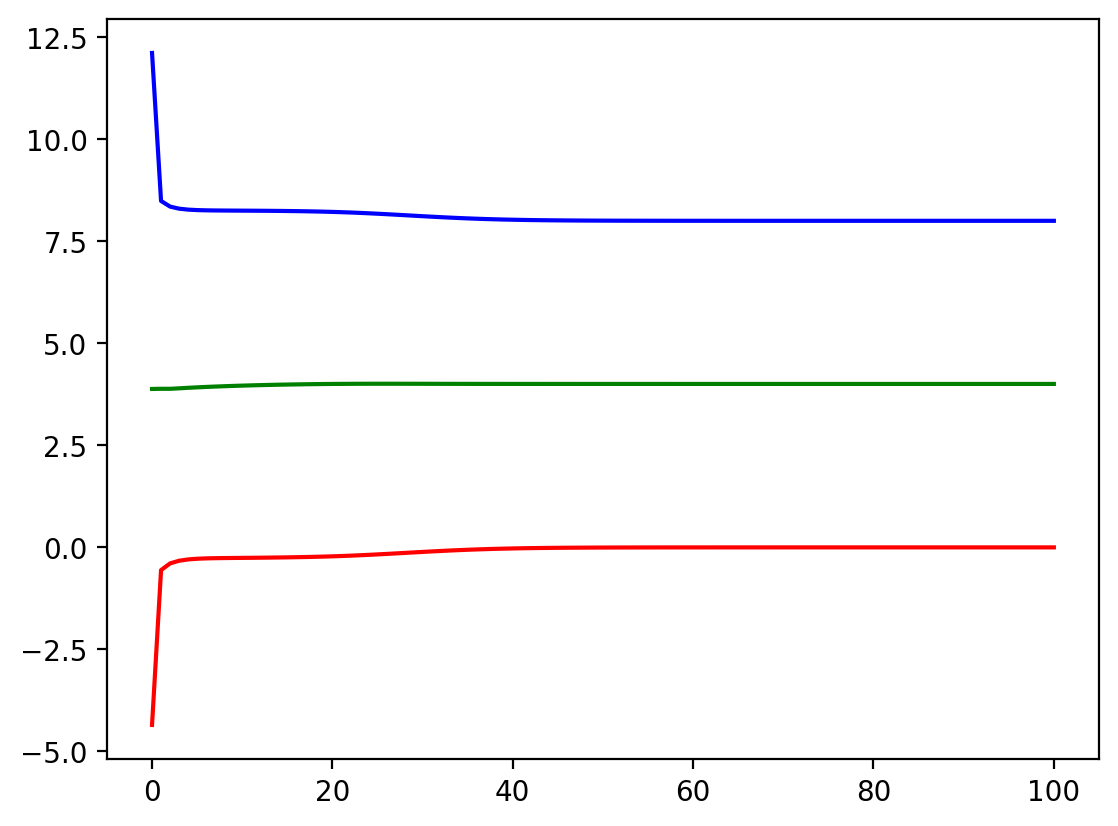

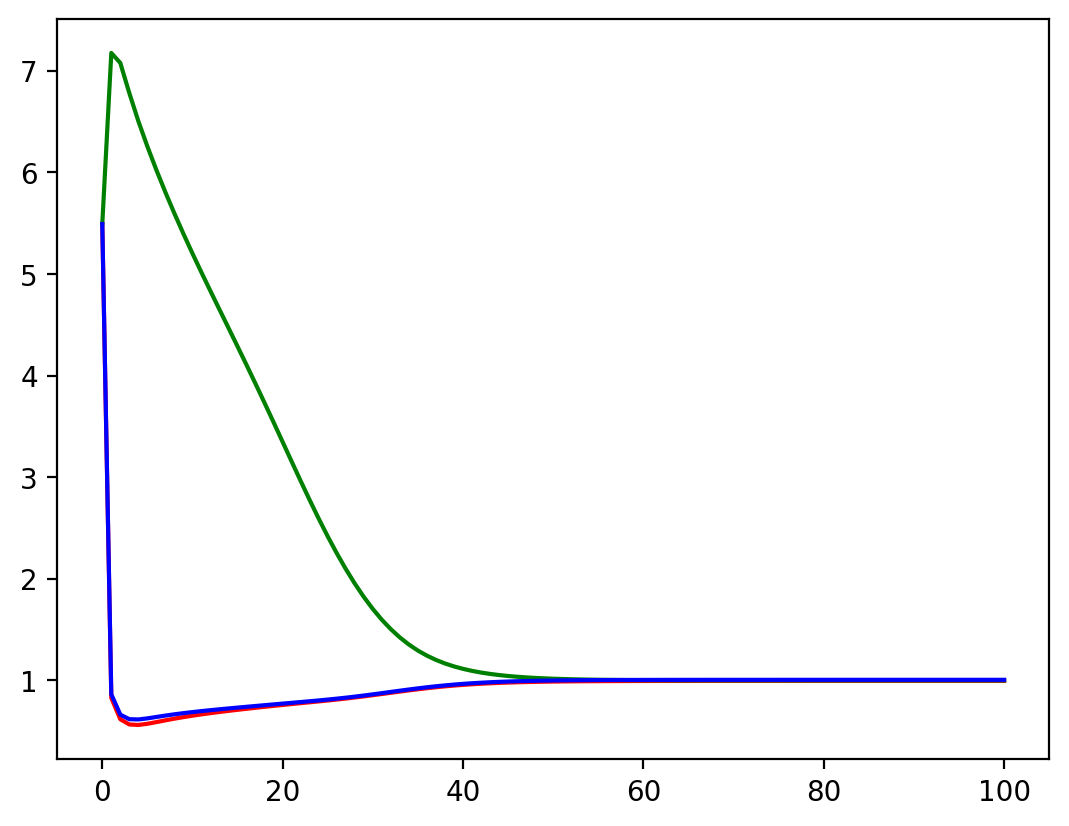

In [50]:
liste_mu = np.array(liste_mu)
liste_sigma = np.array(liste_sigma)
for i in range(F):
    plt.plot(np.squeeze(np.split(liste_mu, 3, axis = 1)[i]), color = couleurs[i])
plt.show()
for i in range(F):
    plt.plot(np.squeeze(np.split(liste_sigma, 3, axis = 1)[i]), color = couleurs[i])
plt.show()

In [ ]:
liste_theta = np.array(liste_theta)
liste_mu = np.split(liste_theta,2, axis = 2)[0]
liste_sigma = np.split(liste_theta,2, axis = 2)[1]